# boston_housing

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
(X_train,y_train),(X_test,y_test) = boston_housing.load_data()

In [3]:
X_train.shape
X_train[0]

array([  1.23247,   0.     ,   8.14   ,   0.     ,   0.538  ,   6.142  ,
        91.7    ,   3.9769 ,   4.     , 307.     ,  21.     , 396.9    ,
        18.72   ])

In [4]:
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [5]:
model =Sequential()
model.add(Dense(8,input_shape=(13,),activation='relu',name='input'))
model.add(Dense(32,activation='relu',name='hidden_01'))
model.add(Dense(1, name='output'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (Dense)               (None, 8)                 112       
                                                                 
 hidden_01 (Dense)           (None, 32)                288       
                                                                 
 output (Dense)              (None, 1)                 33        
                                                                 
Total params: 433
Trainable params: 433
Non-trainable params: 0
_________________________________________________________________


In [6]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [7]:
model.fit(X_train,y_train,epochs=100,batch_size=16,verbose=1)

Epoch 1/100
26/26 [==============================] - 1s 3ms/step - loss: 819.6103 - mae: 22.3200
Epoch 2/100
26/26 [==============================] - 0s 2ms/step - loss: 205.1541 - mae: 10.5016
Epoch 3/100
26/26 [==============================] - 0s 2ms/step - loss: 146.0991 - mae: 9.1997
Epoch 4/100
26/26 [==============================] - 0s 2ms/step - loss: 126.1486 - mae: 8.5160
Epoch 5/100
26/26 [==============================] - 0s 2ms/step - loss: 117.7971 - mae: 8.1837
Epoch 6/100
26/26 [==============================] - 0s 2ms/step - loss: 112.4702 - mae: 7.9400
Epoch 7/100
26/26 [==============================] - 0s 2ms/step - loss: 110.1918 - mae: 8.0104
Epoch 8/100
26/26 [==============================] - 0s 2ms/step - loss: 107.9883 - mae: 7.7279
Epoch 9/100
26/26 [==============================] - 0s 2ms/step - loss: 100.6839 - mae: 7.5643
Epoch 10/100
26/26 [==============================] - 0s 2ms/step - loss: 91.2416 - mae: 7.0894
Epoch 11/100
26/26 [==================

In [8]:
test_mse,test_mae = model.evaluate(X_test,y_test)
print(test_mse,test_mae)

4/4 [==============================] - 0s 5ms/step - loss: 40.6260 - mae: 4.5313
40.625999450683594 4.531267166137695


# 아이오아주 주택가격

In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [10]:
train = pd.read_csv("dataset/house/house_train.csv")
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
test = pd.read_csv("dataset/house/house_test.csv")
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [12]:
train.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
MasVnrType         8
Electrical         1
Id                 0
dtype: int64

In [13]:
# 카테고리형 변수를 0,1으로 변환
df = pd.get_dummies(train)
df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,1,0,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,1,0,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,1,0,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,1,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,1,0,0,0,0,1,0


In [14]:
df = df.fillna(df.mean())
df

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,1,0,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,1,0,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,1,0,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,1,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,0,0,1,0,0,0,0,1,0
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,0,0,0,1,0,0,0,0,1,0
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,0,0,1,0,0,0,0,1,0
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,0,0,0,1,0,0,0,0,1,0


In [15]:
df_corr = df.corr()

In [16]:
df_corr_sort=df_corr.sort_values("SalePrice",ascending=False).head(20)
df_corr_sort['SalePrice'].head(20)

SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.708624
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
FullBath            0.560664
BsmtQual_Ex         0.553105
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
YearRemodAdd        0.507101
KitchenQual_Ex      0.504094
Foundation_PConc    0.497734
MasVnrArea          0.475241
GarageYrBlt         0.470177
Fireplaces          0.466929
ExterQual_Gd        0.452466
ExterQual_Ex        0.451164
BsmtFinType1_GLQ    0.434597
Name: SalePrice, dtype: float64

In [17]:
cols=['SalePrice','OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF','FullBath','BsmtQual_Ex','TotRmsAbvGrd','YearBuilt']

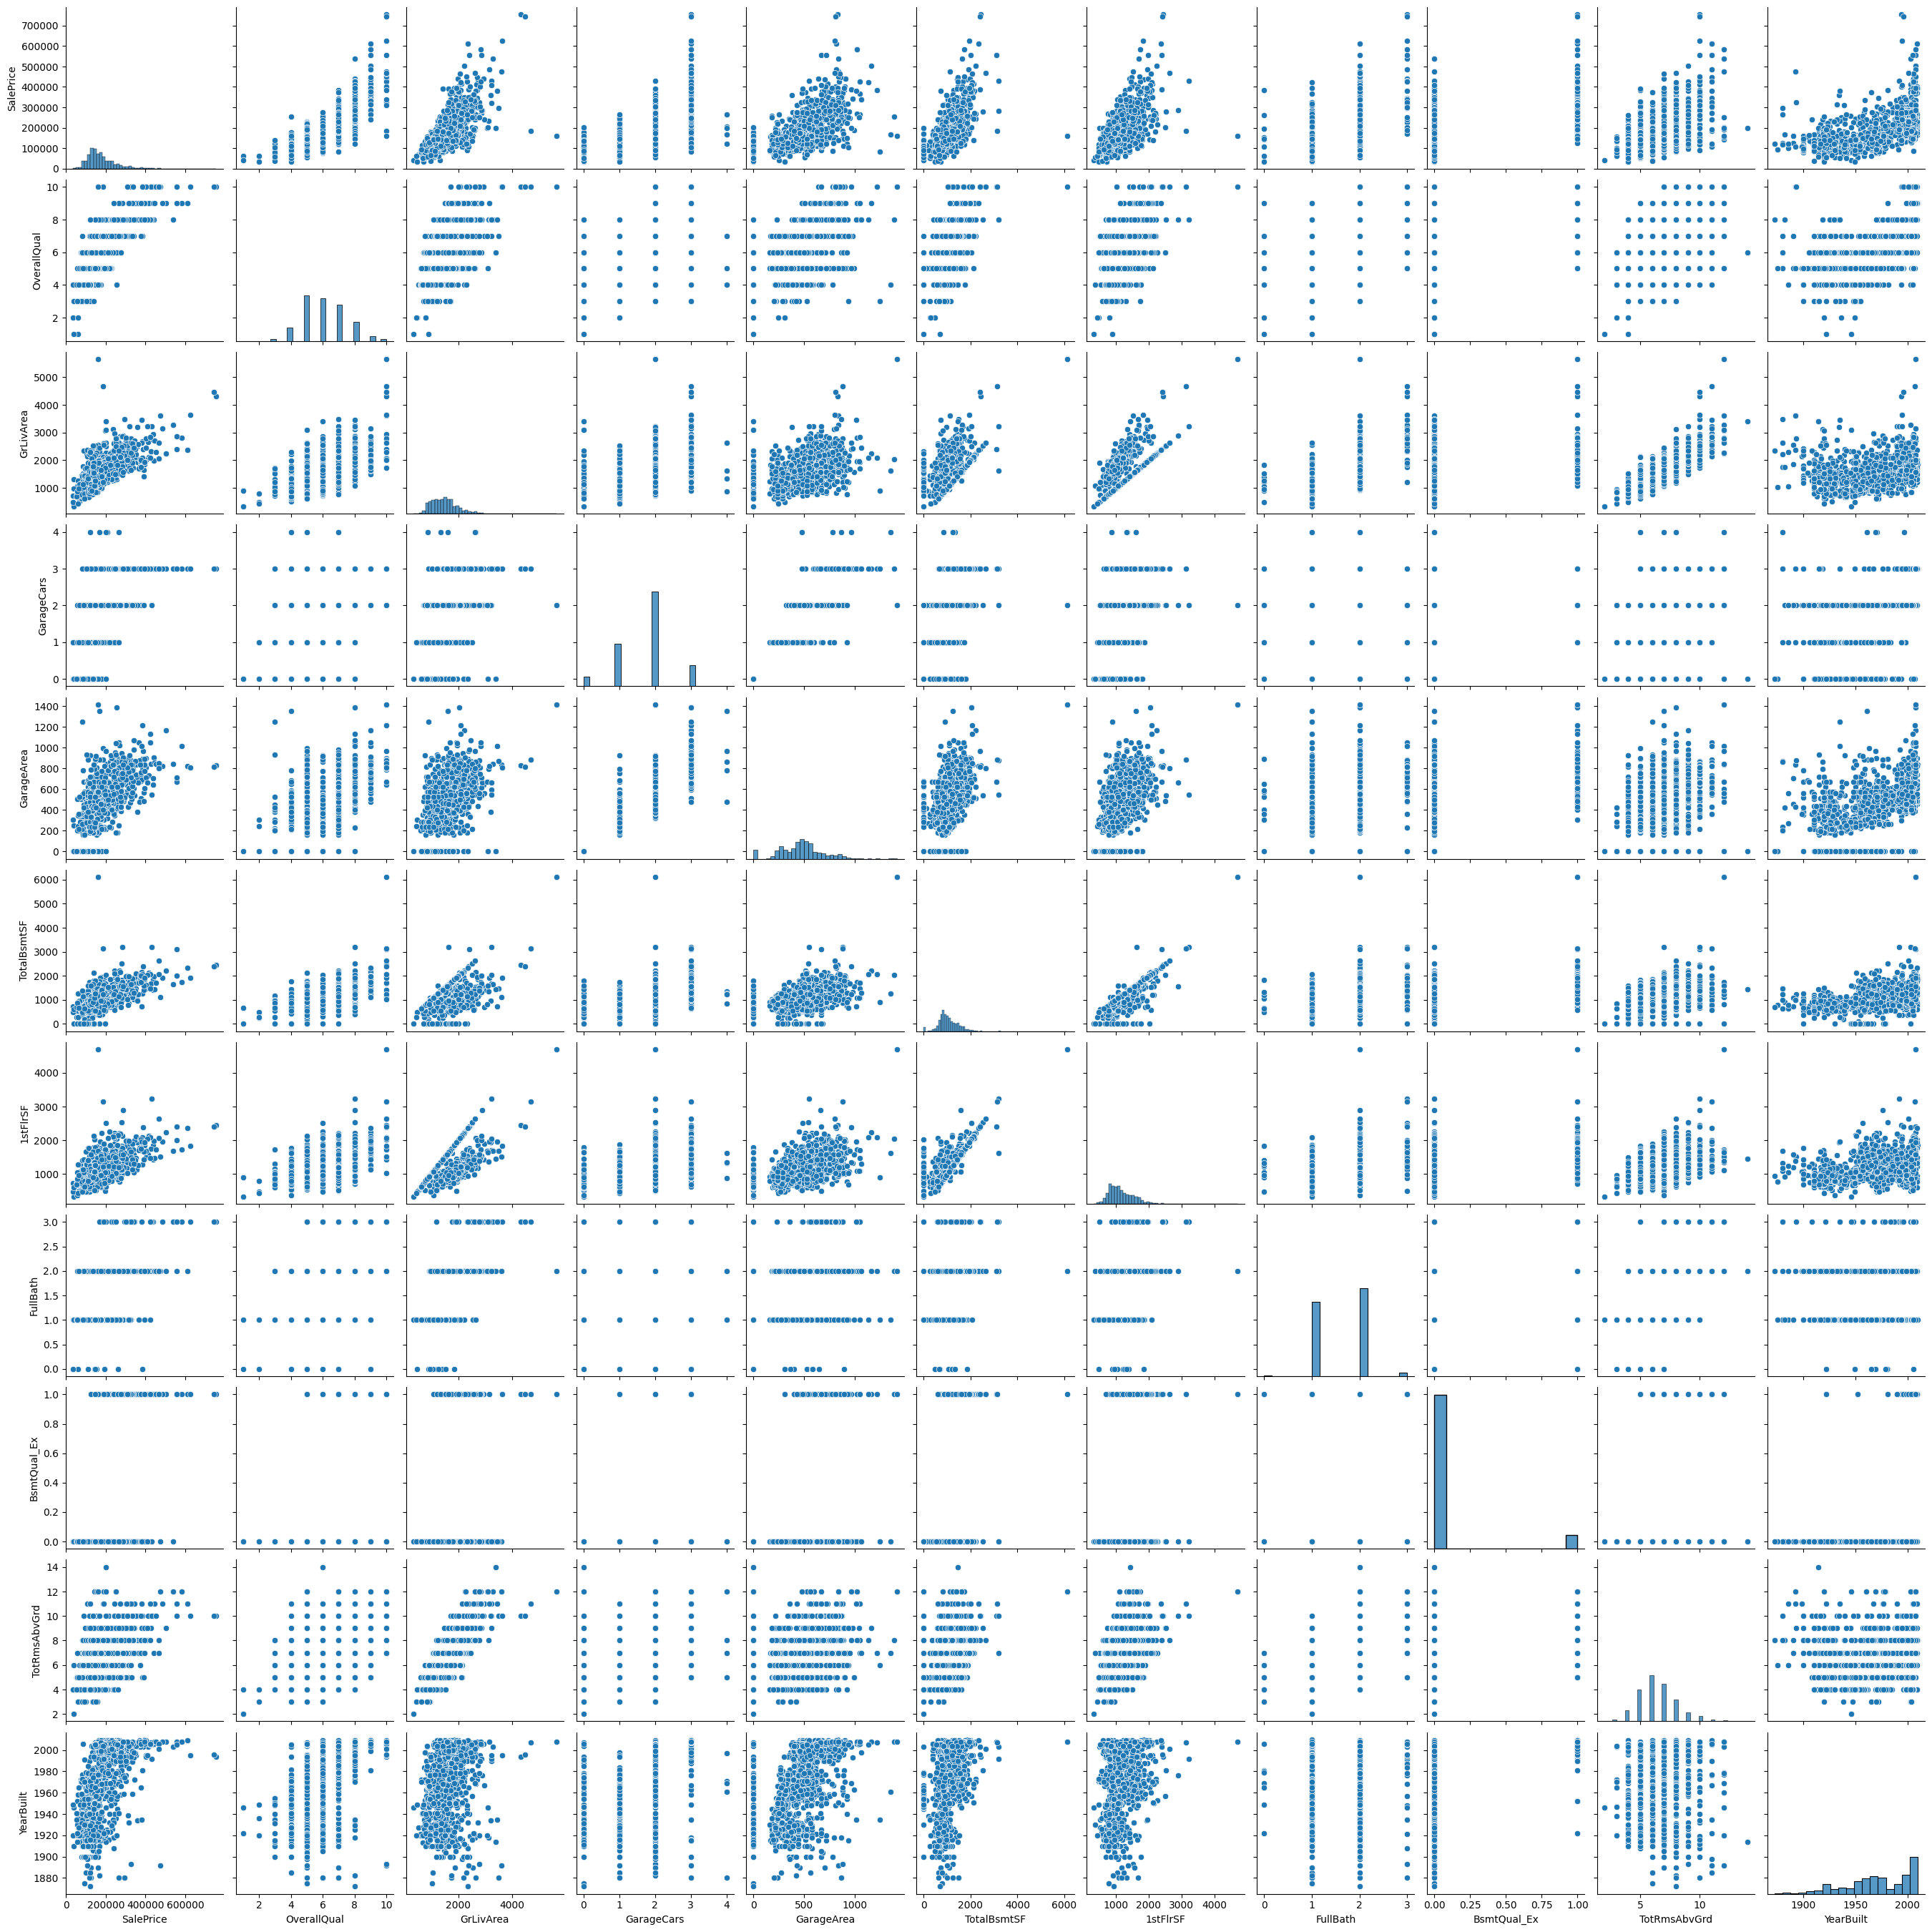

In [18]:
sns.pairplot(df[cols])
plt.show()

In [19]:
cols_train=['OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF','FullBath','BsmtQual_Ex','TotRmsAbvGrd','YearBuilt']

X_train_pre = df[cols_train]
y = df['SalePrice'].values

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X_train_pre,y ,test_size=0.2)

In [21]:
model =Sequential()
model.add(Dense(10,input_shape=(10,),activation='relu',name='input'))
model.add(Dense(20,activation='relu',name='hidden_01'))
model.add(Dense(40,activation='relu',name='hidden_02'))
model.add(Dense(1, name='output'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (Dense)               (None, 10)                110       
                                                                 
 hidden_01 (Dense)           (None, 20)                220       
                                                                 
 hidden_02 (Dense)           (None, 40)                840       
                                                                 
 output (Dense)              (None, 1)                 41        
                                                                 
Total params: 1,211
Trainable params: 1,211
Non-trainable params: 0
_________________________________________________________________


In [22]:
model.compile(optimizer='adam', loss='mse')

In [23]:
eraly_stopping= EarlyStopping(monitor='val_loss',patience=20)
model_path = './test/house/CH15-house.keras'
checkpointer = ModelCheckpoint(filepath=model_path,verbose=0,monitor='val_loss',save_best_only=True)

In [24]:
model.fit(X_train,y_train,epochs=2000,batch_size=32,validation_split=0.25,callbacks=[eraly_stopping,checkpointer])

Epoch 1/2000
28/28 [==============================] - 1s 10ms/step - loss: 40100126720.0000 - val_loss: 36731412480.0000
Epoch 2/2000
28/28 [==============================] - 0s 6ms/step - loss: 39525851136.0000 - val_loss: 35982725120.0000
Epoch 3/2000
28/28 [==============================] - 0s 6ms/step - loss: 38293667840.0000 - val_loss: 34166253568.0000
Epoch 4/2000
28/28 [==============================] - 0s 5ms/step - loss: 35224506368.0000 - val_loss: 29673834496.0000
Epoch 5/2000
28/28 [==============================] - 0s 6ms/step - loss: 28148914176.0000 - val_loss: 20449357824.0000
Epoch 6/2000
28/28 [==============================] - 0s 5ms/step - loss: 16208939008.0000 - val_loss: 8412197376.0000
Epoch 7/2000
28/28 [==============================] - 0s 6ms/step - loss: 5572815360.0000 - val_loss: 2820774144.0000
Epoch 8/2000
28/28 [==============================] - 0s 6ms/step - loss: 3139623680.0000 - val_loss: 2805496832.0000
Epoch 9/2000
28/28 [========================

In [28]:
# 예측값과 실측값

real_price=[]
pred_price=[]
X_num=[]

n_iter = 0
Y_prediction = model.predict(X_test).flatten()

for i in range(25):
    real = y_test[i]
    prediction = Y_prediction[i]
    print('실제 가격 : {:.2f}, 예상 가격 : {:0.2f}'.format(real,prediction))
    real_price.append(real)
    pred_price.append(prediction)
    n_iter = n_iter+1
    X_num.append(n_iter)

10/10 [==============================] - 0s 2ms/step
실제 가격 : 143000.00, 예상 가격 : 161315.70
실제 가격 : 139400.00, 예상 가격 : 117547.27
실제 가격 : 146000.00, 예상 가격 : 165240.28
실제 가격 : 110500.00, 예상 가격 : 154371.08
실제 가격 : 196000.00, 예상 가격 : 194189.33
실제 가격 : 165500.00, 예상 가격 : 205089.22
실제 가격 : 110000.00, 예상 가격 : 105534.98
실제 가격 : 215000.00, 예상 가격 : 216610.42
실제 가격 : 260400.00, 예상 가격 : 228964.78
실제 가격 : 163000.00, 예상 가격 : 203044.83
실제 가격 : 159895.00, 예상 가격 : 166076.61
실제 가격 : 226000.00, 예상 가격 : 218406.97
실제 가격 : 266500.00, 예상 가격 : 215262.05
실제 가격 : 181000.00, 예상 가격 : 181449.66
실제 가격 : 146000.00, 예상 가격 : 196146.48
실제 가격 : 119900.00, 예상 가격 : 118548.51
실제 가격 : 163000.00, 예상 가격 : 188430.03
실제 가격 : 107500.00, 예상 가격 : 88049.83
실제 가격 : 185000.00, 예상 가격 : 225317.09
실제 가격 : 166000.00, 예상 가격 : 193113.11
실제 가격 : 180500.00, 예상 가격 : 202724.64
실제 가격 : 149700.00, 예상 가격 : 204772.47
실제 가격 : 345000.00, 예상 가격 : 302726.56
실제 가격 : 91000.00, 예상 가격 : 123890.77
실제 가격 : 172500.00, 예상 가격 : 193227.84


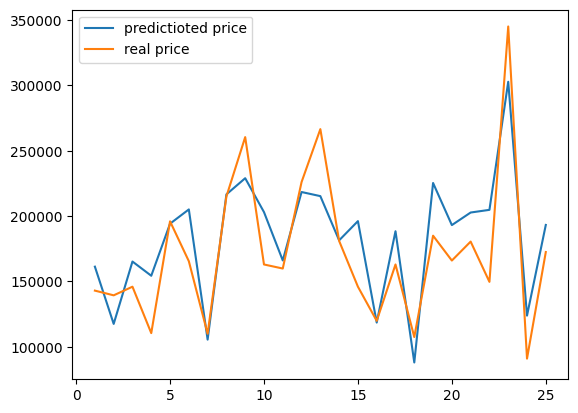

In [29]:
plt.plot(X_num,pred_price,label='predictioted price')
plt.plot(X_num,real_price,label='real price')
plt.legend()
plt.show()